In [2]:
import pandas as pd
df = pd.read_excel("../data/Flood_Research_Final_Dataset.xlsx")
df.head()

,DATE,STATE,CITY,LATITUDE,LONGITUDE,MONTH,YEAR,KERALA MONSOON ONSET DATE,LOCAL MONSOON ONSET DATE,ANTECEDENT RAINFALL (mm),FLOOD OCCURRED,El Nino,La Nina,ENSO,SOIL MOISTURE
0,Jun-2010,Maharashtra,Mumbai,19.076,72.8777,June,2010,2010-05-31,2010-06-11,160,No,No,Yes,Strong La Nina,High
1,Jun-2011,Maharashtra,Mumbai,19.076,72.8777,June,2011,2011-05-29,2011-06-12,120,No,No,Yes,Moderate La Nina,High
2,Jun-2012,Maharashtra,Mumbai,19.076,72.8777,June,2012,2012-06-05,2012-06-12,120,No,No,No,Neutral,Moderate
3,Jun-2013,Maharashtra,Mumbai,19.076,72.8777,June,2013,2013-06-01,2013-06-12,120,No,No,No,Neutral,Moderate
4,29-Sep-2014,Maharashtra,Mumbai,19.076,72.8777,June,2014,2014-06-06,2014-06-15,140,No,Yes,No,Weak El Nino,Moderate


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   DATE                       192 non-null    object        
 1   STATE                      192 non-null    object        
 2   CITY                       192 non-null    object        
 3   LATITUDE                   192 non-null    float64       
 4   LONGITUDE                  192 non-null    float64       
 5   MONTH                      192 non-null    object        
 6   YEAR                       192 non-null    int64         
 7   KERALA MONSOON ONSET DATE  192 non-null    datetime64[ns]
 8   LOCAL MONSOON ONSET DATE   192 non-null    datetime64[ns]
 9   ANTECEDENT RAINFALL (mm)   192 non-null    int64         
 10  FLOOD OCCURRED             192 non-null    object        
 11  El Nino                    192 non-null    object        
 12  La Nina 

In [4]:
df.isnull().sum()

DATE                         0
STATE                        0
CITY                         0
LATITUDE                     0
LONGITUDE                    0
MONTH                        0
YEAR                         0
KERALA MONSOON ONSET DATE    0
LOCAL MONSOON ONSET DATE     0
ANTECEDENT RAINFALL (mm)     0
FLOOD OCCURRED               0
El Nino                      0
La Nina                      0
ENSO                         0
SOIL MOISTURE                0
dtype: int64

In [5]:
df.shape

(192, 15)

In [6]:
df.describe()

,LATITUDE,LONGITUDE,YEAR,KERALA MONSOON ONSET DATE,LOCAL MONSOON ONSET DATE,ANTECEDENT RAINFALL (mm)
count,192.000000,192.000000,192.000000,192,192,192.000000
mean,19.493642,79.019992,2017.500000,2017-12-01 15:00:00,2017-12-11 22:00:00,118.182292
min,9.931200,72.571400,2010.000000,2010-05-31 00:00:00,2010-06-01 00:00:00,47.000000
25%,16.309425,73.687825,2013.750000,2014-03-05 12:00:00,2014-03-08 12:00:00,90.000000
50%,19.686050,77.401800,2017.500000,2017-11-28 00:00:00,2017-12-14 00:00:00,100.000000
75%,22.685075,81.659150,2021.250000,2021-09-01 00:00:00,2021-09-19 00:00:00,130.000000
max,28.613900,91.736200,2025.000000,2025-05-27 00:00:00,2025-06-28 00:00:00,300.000000
std,5.325441,6.140501,4.621824,NaN,NaN,48.548169


In [7]:
df.columns

Index(['DATE', 'STATE', 'CITY', 'LATITUDE', 'LONGITUDE', 'MONTH', 'YEAR',
       'KERALA MONSOON ONSET DATE', 'LOCAL MONSOON ONSET DATE',
       'ANTECEDENT RAINFALL (mm)', 'FLOOD OCCURRED', 'El Nino', 'La Nina',
       'ENSO', 'SOIL MOISTURE'],
      dtype='object')

In [8]:
df["FLOOD OCCURRED"].value_counts()

FLOOD OCCURRED
No     167
Yes     25
Name: count, dtype: int64

In [9]:
df.groupby("CITY")["FLOOD OCCURRED"].value_counts()

CITY         FLOOD OCCURRED
Ahmedabad    No                14
             Yes                2
Bengaluru    No                14
             Yes                2
Bhubaneswar  No                16
Chennai      No                13
             Yes                3
Guwahati     No                16
Hyderabad    No                14
             Yes                2
Kochi        No                16
Kolkata      No                12
             Yes                4
Mumbai       No                10
             Yes                6
New Delhi    No                15
             Yes                1
Pune         No                14
             Yes                2
Vadodara     No                13
             Yes                3
Name: count, dtype: int64

In [11]:
df.groupby("CITY")["ANTECEDENT RAINFALL (mm)"].mean()

CITY
Ahmedabad      111.8750
Bengaluru      110.0000
Bhubaneswar     66.4375
Chennai        133.7500
Guwahati        98.0625
Hyderabad      116.5625
Kochi          113.6875
Kolkata        153.1250
Mumbai         165.0000
New Delhi      102.1875
Pune           126.2500
Vadodara       121.2500
Name: ANTECEDENT RAINFALL (mm), dtype: float64

In [12]:
df.columns = df.columns.str.strip()

In [13]:
df.groupby("CITY")["FLOOD OCCURRED"].value_counts()

CITY         FLOOD OCCURRED
Ahmedabad    No                14
             Yes                2
Bengaluru    No                14
             Yes                2
Bhubaneswar  No                16
Chennai      No                13
             Yes                3
Guwahati     No                16
Hyderabad    No                14
             Yes                2
Kochi        No                16
Kolkata      No                12
             Yes                4
Mumbai       No                10
             Yes                6
New Delhi    No                15
             Yes                1
Pune         No                14
             Yes                2
Vadodara     No                13
             Yes                3
Name: count, dtype: int64

In [14]:
df[df["FLOOD OCCURRED"] == "Yes"]["ANTECEDENT RAINFALL (mm)"].mean()

226.0

In [15]:
df[df["FLOOD OCCURRED"] == "No"]["ANTECEDENT RAINFALL (mm)"].mean()

102.04191616766467

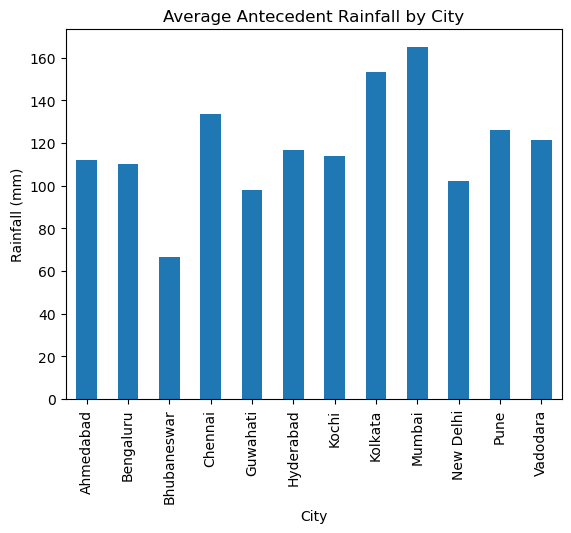

In [16]:
import matplotlib.pyplot as plt

df.groupby("CITY")["ANTECEDENT RAINFALL (mm)"].mean().plot(kind="bar")

plt.title("Average Antecedent Rainfall by City")
plt.xlabel("City")
plt.ylabel("Rainfall (mm)")

plt.show()